In [76]:
from DDiT import Disk
import matplotlib.pyplot as plt
import numpy as np
import h5py
from datetime import datetime
from PIL import Image


In [53]:
# Disk parameters
disk_params = {
    'nx' : 300,             # Size of the image in pixels
    'pixscale' : 0.01226,   # Size of one pixel in arcseconds
    'nframe' : 50,          # Number of frames (see above)
    'thermal' : False,       # A boolean
    'dpc' : 35.34,          # Distance of the central star in pc
}

In [54]:
def normalized_data(data):
    # Normalize the data to the range 0-255
    return (data - np.min(data)) / (np.max(data) - np.min(data)) * 255

def dict_to_string(d):
    return '-'.join(f'{key}{value}' for key, value in d.items())

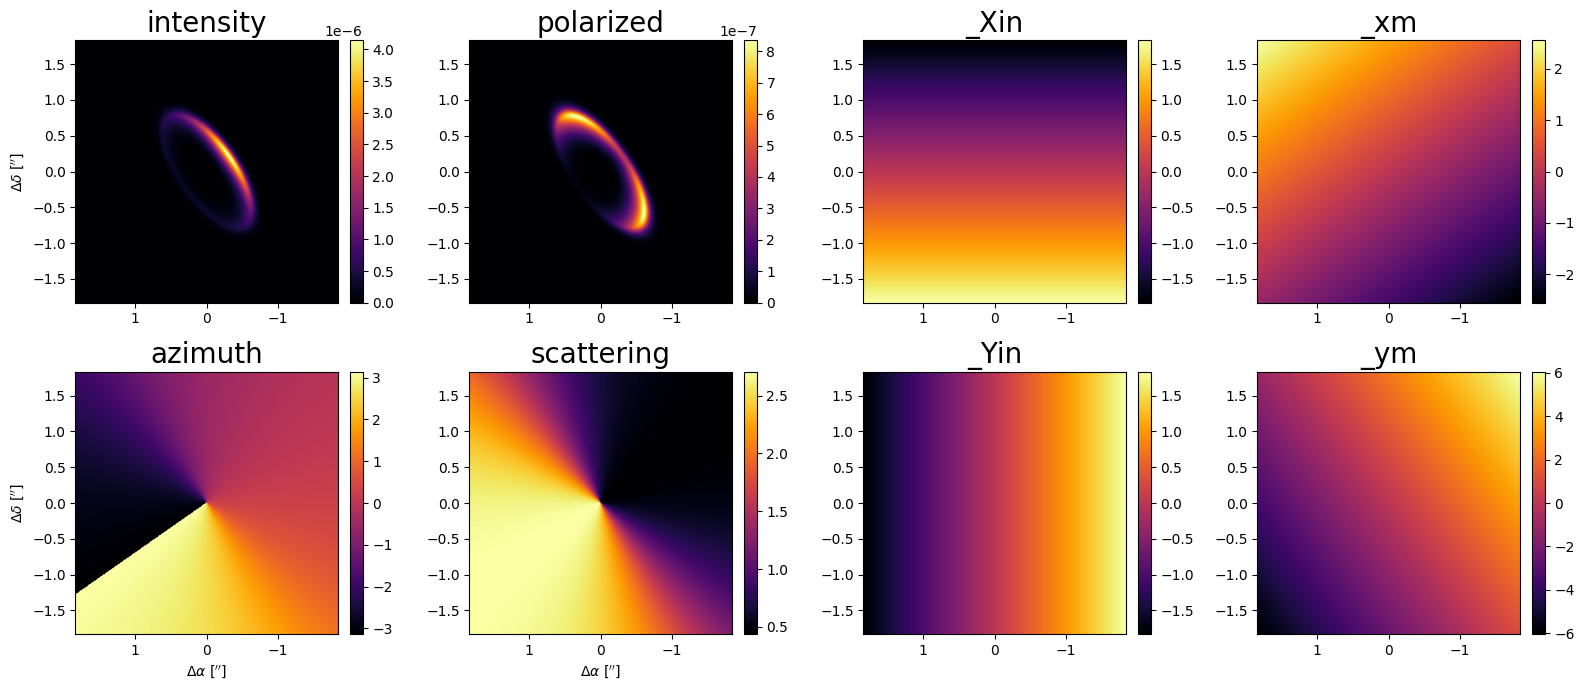

In [80]:
from DDiT import Disk
disk = Disk(**disk_params)

# Compute model parameters
model_params = {
    'a' : 0.95,             # Semi-major axis of the disk in arcseconds
    'incl' :65.,           # Inclination, in degrees
    'pa' : 145,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.0,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
    'wave' : 1200,          # Wavelength in units of microns.

}
disk.compute_model(**model_params)

fig, axs = plt.subplots(2, 4, figsize=(16, 7))
properties = ['intensity', 'polarized', "_Xin", "_xm", 'azimuth', 'scattering', "_Yin", "_ym"]
for ax, prop_name in zip(axs.ravel(), properties):
    data = getattr(disk, prop_name)
    # cax = ax.imshow(np.rot90(data, 2), extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno')
    cax = ax.imshow(data, extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno')
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    ax.set_title(f'{prop_name}', fontsize=20)
    if prop_name in ['azimuth', 'scattering']:
        ax.set_xlabel('$\Delta \\alpha$ [$^{\prime\prime}$]')
    if prop_name in ['intensity', 'azimuth']:
        ax.set_ylabel('$\Delta \\delta$ [$^{\prime\prime}$]')

plt.tight_layout()
#plt.subplots_adjust(hspace=-0.15, wspace=0.2)  # Adjust the space between plots
#plt.savefig('output/images/{}_combined_plot.png'.format(dict_to_string(model_params)))
plt.show()

In [89]:
polarized_nan = disk.polarized.copy()
polarized_nan[polarized_nan == 0.0] = np.NaN

phi_polar = np.arctan2(disk._Yin,disk._Xin)
Q = -polarized_nan * np.cos(2*phi_polar)
U = -polarized_nan * np.sin(2*phi_polar)
theta = 0.5*np.arctan2(U, Q)

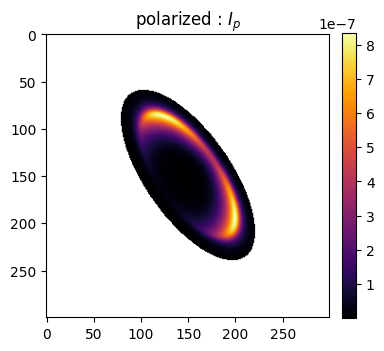

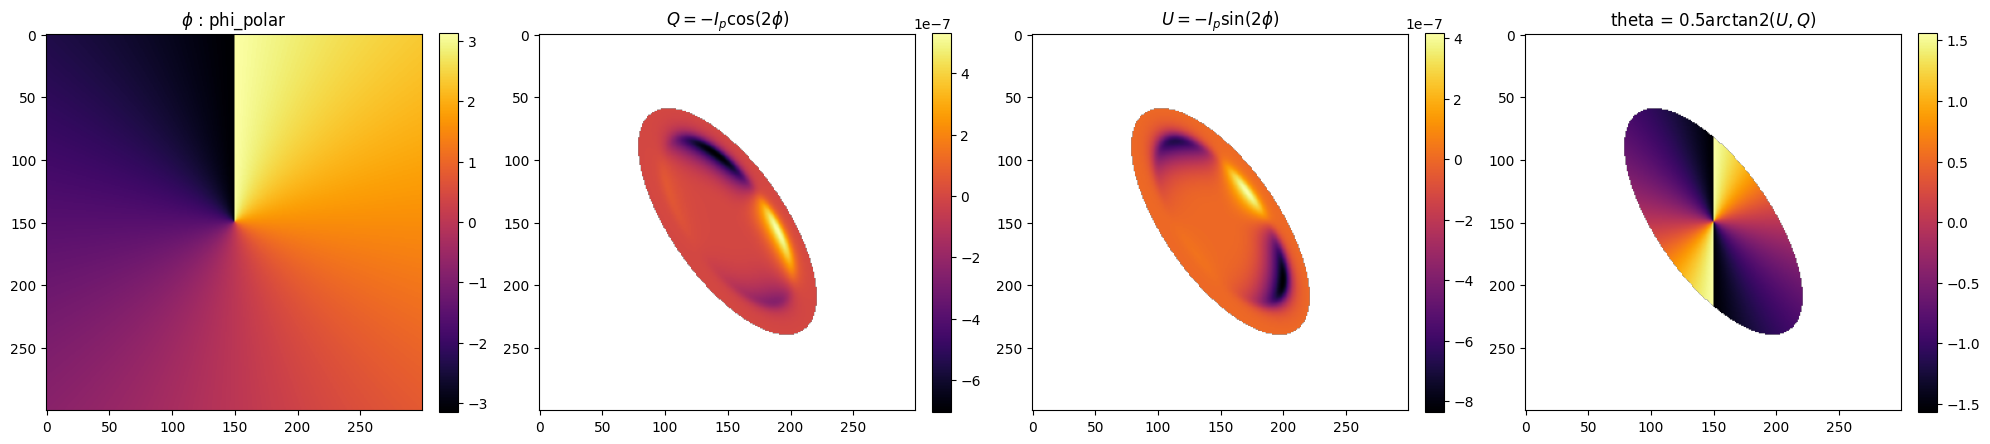

In [90]:
plt.figure(figsize=(4, 4))
plt.imshow(polarized_nan, cmap='inferno')
plt.title('polarized : $I_p$')
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# Plot phi_polar
axs[0].imshow(phi_polar, cmap='inferno')
axs[0].set_title('$\phi$ : phi_polar')
fig.colorbar(axs[0].images[0], ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)

# Plot Q
axs[1].imshow(Q, cmap='inferno')
axs[1].set_title('$Q=-I_p\cos(2\phi)$')
fig.colorbar(axs[1].images[0], ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)

# Plot U
axs[2].imshow(U, cmap='inferno')
axs[2].set_title('$U=-I_p\sin(2\phi)$')
fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)

# Plot theta
axs[3].imshow(theta, cmap='inferno')
axs[3].set_title('theta = $0.5$arctan2($U, Q$)')
fig.colorbar(axs[3].images[0], ax=axs[3], orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Testing if wave got an impact

In [71]:
previous_intensity = np.zeros((300,300))
previous_polarized = np.zeros((300,300))
wavelength = np.array([900,1200, 1600, 2200])

for i, wave in enumerate(wavelength):

    # Compute model parameters
    model_params = {
        'a' : 0.95,             # Semi-major axis of the disk in arcseconds
        'incl' :75.,            # Inclination, in degrees
        'pa' : 145,             # Position angle, in degrees
        'pin' : 5.0,            # Inner slope of the density distribution (>0)
        'pout' : -15.0,         # Outer slope of the density distribution (<0)
        'e' : 0.0,              # Eccentricity
        'omega' : 85.,          # Argument of periapsis, in degrees
        'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
        'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
        'opang' : 0.03,         # Opening angle of the disk, in radians
        'wave' : wave,          # Wavelength in units of microns.
    }
    disk.compute_model(**model_params)

    # Printing diff to see the impact 
    if i != 0:
        intensity_norm_changes = np.linalg.norm(disk.intensity - previous_intensity)
        polarized_norm_changes = np.linalg.norm(disk.polarized - previous_polarized)

        print(f"#{i} wavelength comparaison: ({wavelength[i-1]},{wavelength[i]})")
        print(f"diff_intensity= {intensity_norm_changes}")
        print(f"diff_polarized= {polarized_norm_changes}\n")

    previous_intensity = disk.intensity
    previous_polarized = disk.polarized

#1 wavelength comparaison:(900,1200)
diff_intensity= 0.0
diff_polarized= 0.0

#2 wavelength comparaison:(1200,1600)
diff_intensity= 0.0
diff_polarized= 0.0

#3 wavelength comparaison:(1600,2200)
diff_intensity= 0.0
diff_polarized= 0.0



In [72]:
previous_intensity = np.zeros((300,300))
previous_polarized = np.zeros((300,300))
incl = np.linspace(0,90,3)

for i, inc in enumerate(incl):

    # Compute model parameters
    model_params = {
        'a' : 0.95,             # Semi-major axis of the disk in arcseconds
        'incl' :inc,            # Inclination, in degrees
        'pa' : 145,             # Position angle, in degrees
        'pin' : 5.0,            # Inner slope of the density distribution (>0)
        'pout' : -15.0,         # Outer slope of the density distribution (<0)
        'e' : 0.0,              # Eccentricity
        'omega' : 85.,          # Argument of periapsis, in degrees
        'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
        'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
        'opang' : 0.03,         # Opening angle of the disk, in radians
        'wave' : 900,          # Wavelength in units of microns.
    }
    disk.compute_model(**model_params)

    # Printing diff to see the impact 
    if i != 0:
        intensity_norm_changes = np.linalg.norm(disk.intensity - previous_intensity)
        polarized_norm_changes = np.linalg.norm(disk.polarized - previous_polarized)

        print(f"#{i} incl comparaison: ({incl[i-1]},{incl[i]})")
        print(f"diff_intensity= {intensity_norm_changes}")
        print(f"diff_polarized= {polarized_norm_changes}\n")

    previous_intensity = disk.intensity
    previous_polarized = disk.polarized

#1 incl comparaison: (0.0,45.0)
diff_intensity= 4.159748076880934e-05
diff_polarized= 2.2007525940835118e-05

#2 incl comparaison: (45.0,90.0)
diff_intensity= 0.0002933777900336339
diff_polarized= 7.120614991024812e-05



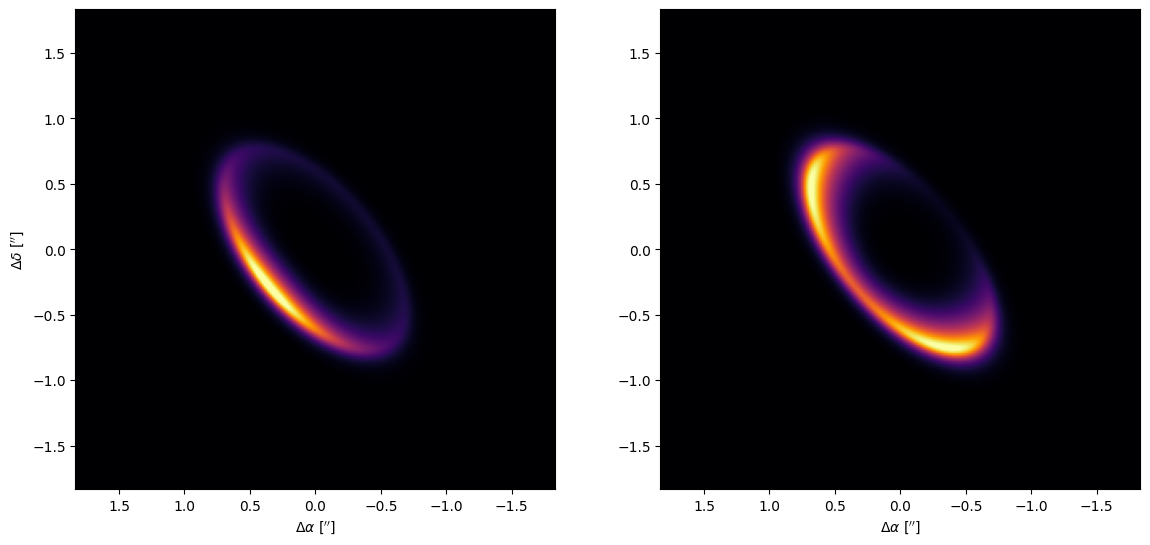

In [62]:
disk.plot()

### Generate and Save images

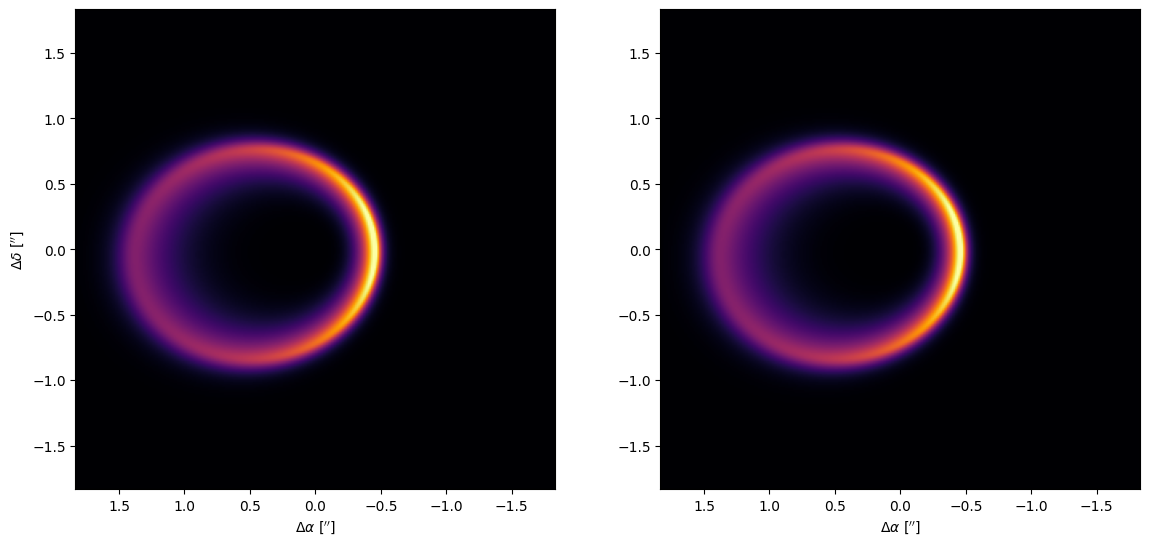

(300, 300)


In [37]:
from PIL import Image

# Compute model parameters
model_params = {
    'a' : 0.95,             # Semi-major axis of the disk in arcseconds
    'incl' : 0.,           # Inclination, in degrees
    'pa' : 0.,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.5,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
}
disk.compute_model(**model_params)
disk.plot()
print(disk.polarized.shape)

# Save the intensity image
intensity_image = Image.fromarray(normalized_data(disk.intensity).astype(np.uint8), 'L')
intensity_image.save('output/images/{}_intensity.bmp'.format(dict_to_string(model_params)))

# Save the polarized image
polarized_image = Image.fromarray(normalized_data(disk.polarized).astype(np.uint8), 'L')
polarized_image.save('output/images/{}_polarized.bmp'.format(dict_to_string(model_params)))

# Save the azimuth image
azimuth_image = Image.fromarray(normalized_data(disk.azimuth).astype(np.uint8), 'L')
azimuth_image.save('output/images/{}_azimuth.bmp'.format(dict_to_string(model_params)))

# Save the scattering image
scattering_image = Image.fromarray(normalized_data(disk.scattering).astype(np.uint8), 'L')
scattering_image.save('output/images/{}_scattering.bmp'.format(dict_to_string(model_params)))

In [77]:
# Create an RGB image using intensity, polarized, and azimuth data
rgb_image = np.zeros((disk.intensity.shape[0], disk.intensity.shape[1], 3), dtype=np.uint8)
rgb_image[..., 0] = normalized_data(disk.intensity).astype(np.uint8)  # Red channel
rgb_image[..., 1] = normalized_data(disk.polarized).astype(np.uint8)  # Green channel
rgb_image[..., 2] = normalized_data(disk.scattering).astype(np.uint8)    # Blue channel

# Save the RGB image
rgb_image_pil = Image.fromarray(rgb_image, 'RGB')
rgb_image_pil.save('output/images_rgb/{}_rgb.bmp'.format(dict_to_string(model_params)))

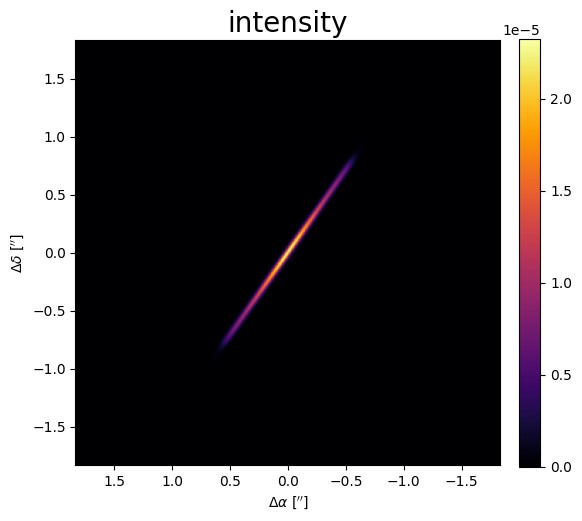

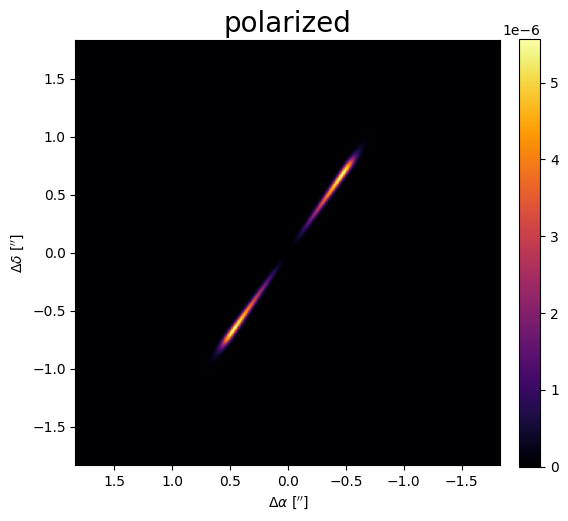

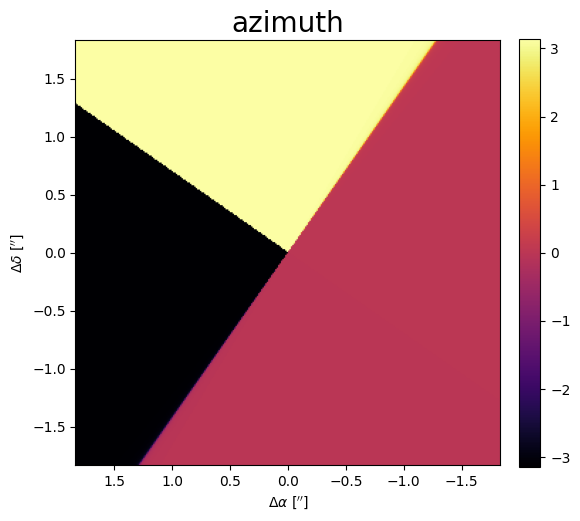

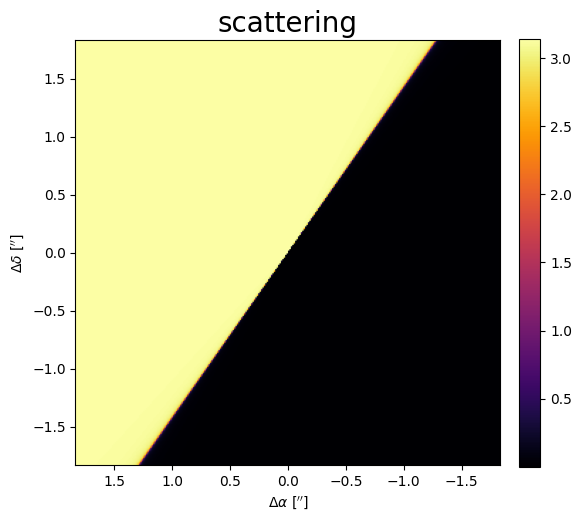

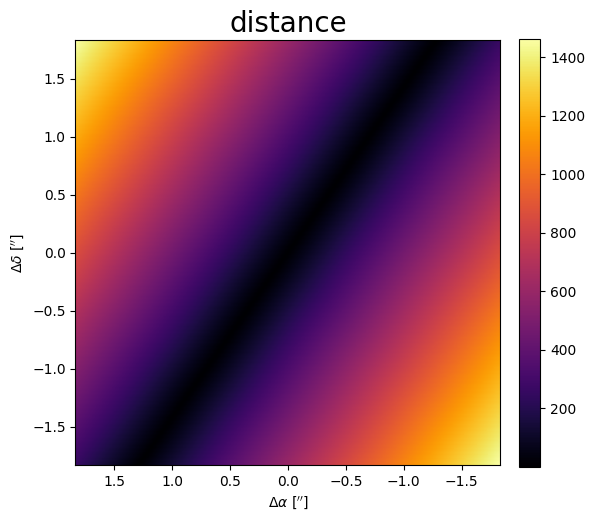

In [78]:
def plot_and_save(disk, model_params, prop_name):
    data = getattr(disk, prop_name)
    fig, ax = plt.subplots(figsize=(6, 6))
    cax = ax.imshow(data, origin='lower', extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno', vmin=np.min(data), vmax=np.max(data))
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    ax.set_xlabel('$\Delta \\alpha$ [$^{\prime\prime}$]')
    ax.set_ylabel('$\Delta \delta$ [$^{\prime\prime}$]')
    plt.title(f'{prop_name}', fontsize=20)
    plt.savefig('output/images/{}_{}_plot.png'.format(dict_to_string(model_params), prop_name))
    plt.show()
    
plot_and_save(disk, model_params, 'intensity')
plot_and_save(disk, model_params, 'polarized')
plot_and_save(disk, model_params, 'azimuth')
plot_and_save(disk, model_params, 'scattering')
plot_and_save(disk, model_params, 'distance')

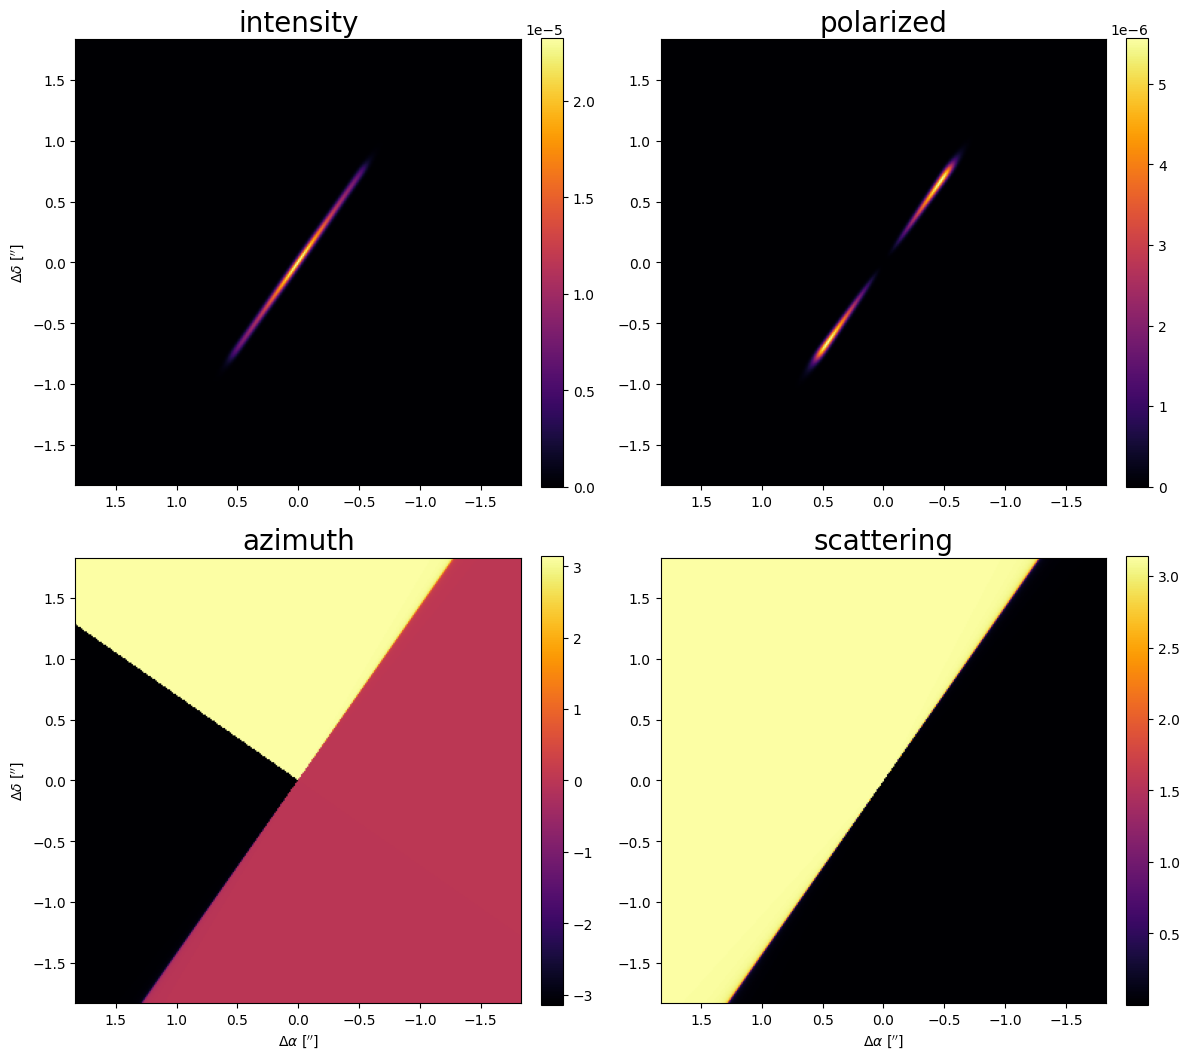

In [79]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

properties = ['intensity', 'polarized', 'azimuth', 'scattering']
for ax, prop_name in zip(axs.ravel(), properties):
    data = getattr(disk, prop_name)
    cax = ax.imshow(data, origin='lower', extent=[disk._xlim, -disk._xlim, -disk._xlim, disk._xlim], cmap='inferno', vmin=np.min(data), vmax=np.max(data))
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
    ax.set_title(f'{prop_name}', fontsize=20)
    if prop_name in ['azimuth', 'scattering']:
        ax.set_xlabel('$\Delta \\alpha$ [$^{\prime\prime}$]')
    if prop_name in ['intensity', 'azimuth']:
        ax.set_ylabel('$\Delta \\delta$ [$^{\prime\prime}$]')

plt.tight_layout()
plt.subplots_adjust(hspace=-0.15, wspace=0.2)  # Adjust the space between plots
plt.savefig('output/images/{}_combined_plot.png'.format(dict_to_string(model_params)))
plt.show()

# Generate dataset

In [6]:
# Compute model parameters
model_params = {
    'a' : np.array([0.95, 1.5]),             # Semi-major axis of the disk in arcseconds
    'incl' : [60., 110.],           # Inclination, in degrees
    'pa' : 112.,            # Position angle, in degrees
    'pin' : 5.0,            # Inner slope of the density distribution (>0)
    'pout' : -15.0,         # Outer slope of the density distribution (<0)
    'e' : 0.1,              # Eccentricity
    'omega' : 85.,          # Argument of periapsis, in degrees
    'gsca' : 0.5,           # Henyey-Greenstein coefficient for total intensity
    'gpol' : 0.5,           # Henyey-Greenstein coefficient for polarized intensity
    'opang' : 0.03,         # Opening angle of the disk, in radians
}

In [7]:
def recursive_compute_model(params, input_disk):
    for key, value in params.items():
        # If list in the 
        if isinstance(value, list) or isinstance(value, np.ndarray):
            for v in value:
                temp_params = params.copy()
                temp_params[key] = v
                recursive_compute_model(temp_params, input_disk)
            return
    print("a : {}, incl : {}".format(params['a'], params['incl']))
    input_disk.compute_model(**params)
    input_disk.plot()

a : 0.95, incl : 60.0


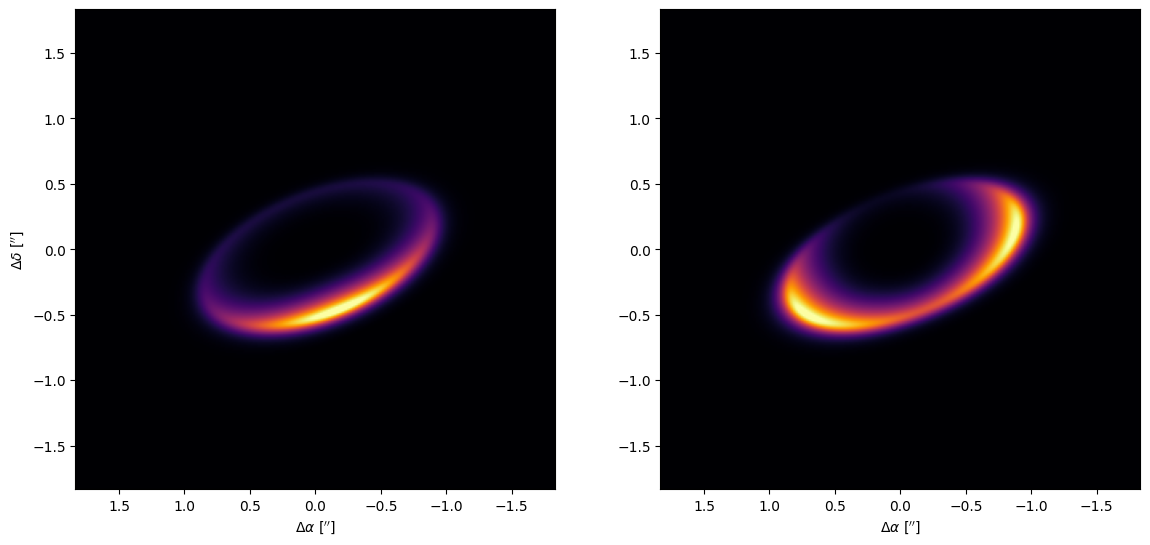

a : 0.95, incl : 110.0


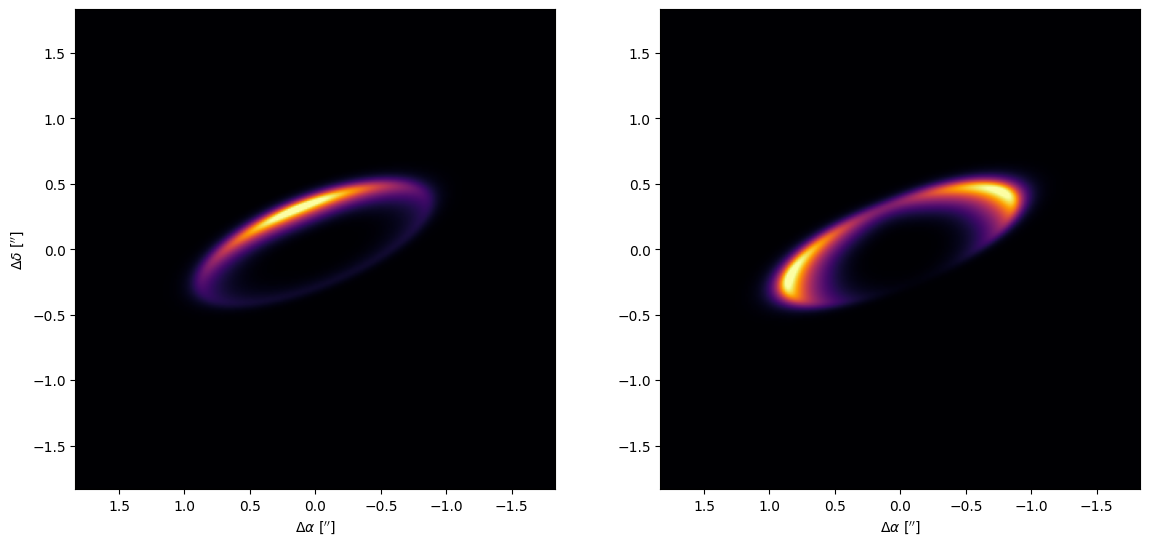

a : 1.5, incl : 60.0


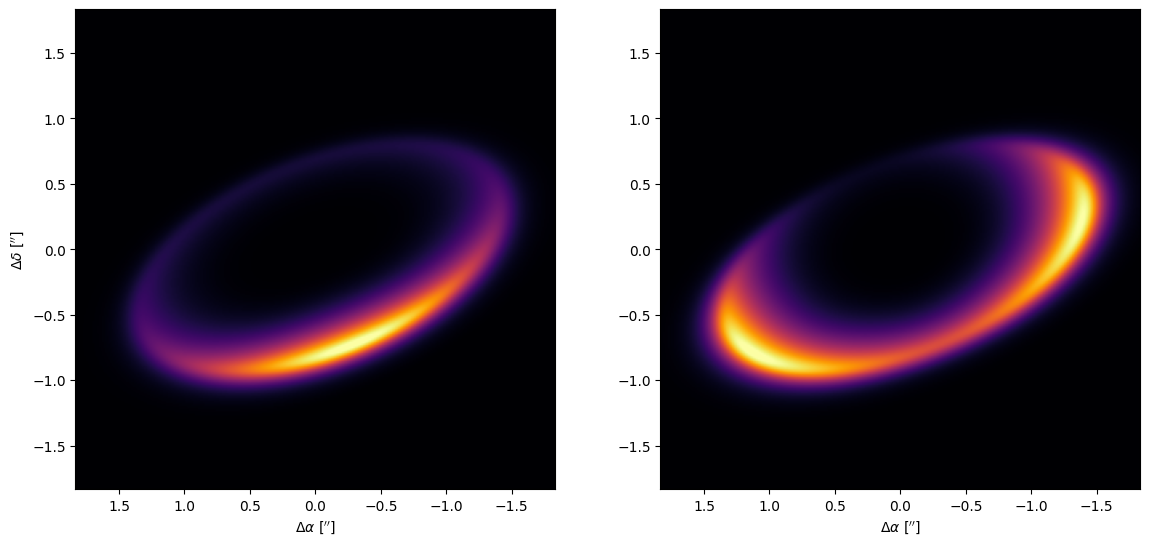

a : 1.5, incl : 110.0


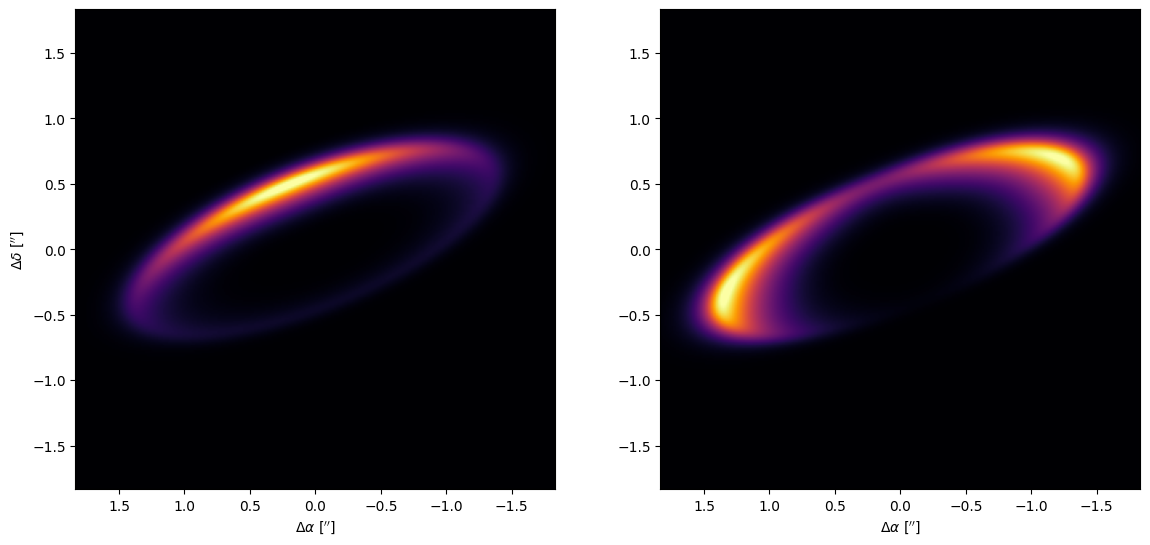

In [8]:
recursive_compute_model(model_params, disk)

Took: 0.76 seconds.
(300, 300)


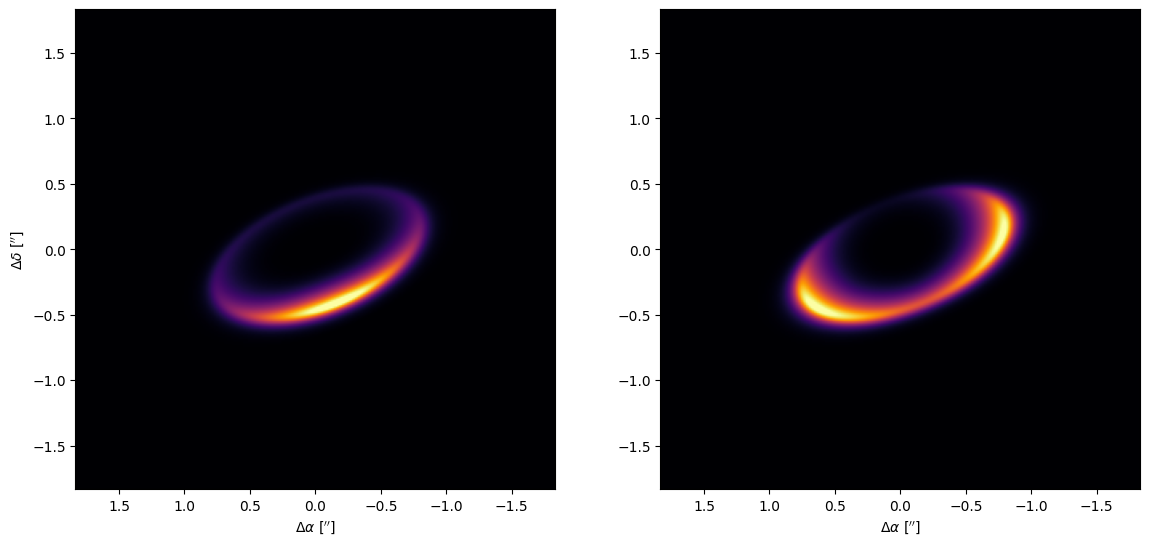

In [23]:
import time

disk = Disk(**disk_params)
#disk = Disk(nx, pixscale, nframe, thermal, dpc)
t0 = time.time()
disk.compute_model(**model_params)
print('Took: ' + format(time.time()-t0, '0.2f') + ' seconds.')
print(disk.intensity.shape)
disk.plot()

# HDF5 Dataset Generation

In [ ]:
#The parameters values
a = np.linspace(0.2,0.8,5)
incl = np.linspace(0,90,3)
pa = np.linspace(0,180,3)
e = np.linspace(0,0.6,3)
wave = np.array([900,1200, 1600, 2200])
presentime = datetime.now()


disk = Disk()

N = 10000  # Nombre de triplets
disk_data = np.zeros((N, 3, 300, 300), dtype=np.float64)  # Images aléatoires
labels = np.zeros((N, 5), dtype=np.float64)  # 5 valeurs par triplet


i_loop = 0
for i in range(len(a)):
    disk.a = a[i]
    for j in range(len(incl)):
        disk.incl = incl[j]
        for l in range(len(pa)):
            disk.pa = pa[l]
            for b in range(len(e)):
                disk.e = e[b]
                for m in range(len(wave)):
                    disk.wave = wave[m]

                    #Compute the model with the values above 
                    disk_model= disk.compute_model()

                    disk_data[i_loop, 0] = 


                    i_loop += 1
                    print((datetime.now() - presentime)/i_loop)
                    disk_data
                    
                    #hdr["Datetime"] = (presentime.strftime('%d/%m/%Y - %T'), " Date and the time of image creation")

print(i_loop)

0:00:02.487717
0:00:01.949518
0:00:01.767823
0:00:01.678310
0:00:01.716728
0:00:01.742409
0:00:01.760897
0:00:01.775481
0:00:01.833843
0:00:01.880421
0:00:01.918397
0:00:01.950544
0:00:01.910047
0:00:01.875291
0:00:01.844942
0:00:01.818570


KeyboardInterrupt: 

In [ ]:
import numpy as np

# Créer des nombres flottants en double précision et en simple précision
a_float64 = np.float64(1.12345678901234567890)
a_float32 = np.float32(1.12345678901234567890)

# Afficher les valeurs et les types de données
print("np.float64:", a_float64, "dtype:", a_float64.dtype)
print("np.float32:", a_float32, "dtype:", a_float32.dtype)

### Writing HDF5

In [ ]:
N = 10000  # Nombre de triplets
disk_data = np.random.rand(N, 3, 300, 300).astype(np.float32)  # Images aléatoires
labels = np.random.rand(N, 5).astype(np.float32)  # 5 valeurs par triplet

# Création du fichier HDF5
with h5py.File("dataset.h5", "w") as f:
    dset = f.create_dataset("disk_data", data=disk_data, compression="gzip")
    f.create_dataset("labels", data=labels, compression="gzip")

    # Ajout des métadonnées en tant qu'attributs
    dset.attrs["description"] = "Disks dataset (Unpolarized intensity, Polarized ) d'images 300x300 avec 5 méta-données par triplet"
    dset.attrs["param_names"] = ["param1", "param2", "param3", "param4", "param5"]

print("Fichier HDF5 avec labels et métadonnées créé avec succès !")

### Reading HDF5

In [ ]:
with h5py.File("dataset.h5", "r") as f:
    data = f["triplets"][0]       # Premier triplet (shape: (3, 300, 300))
    meta = f["labels"][0]         # Méta-données associées (shape: (5,))
    param_names = f["triplets"].attrs["param_names"]
    
print("Triplet chargé :", data.shape)
print("Méta-données associées :", meta)

### Testing writing+reading